fixing

In [19]:
import os
import zipfile
import glob
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

zip_path = '/content/Data.zip'
extract_path = '/content/solar_panel_dataset'

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Could not find your zip file at {zip_path}. Please make sure it finished uploading.")

print(f"Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

# Automatically handle potential nested structures inside the zip archive
subdirs = [d for d in glob.glob(f"{extract_path}/**", recursive=True) if os.path.isdir(d)]
DATA_DIR = None

for sdir in subdirs:
    children = os.listdir(sdir)
    if any(cls in [c.lower() for c in children] for cls in ['Snow-Covered', 'Electrical-damage', 'Dusty', 'Physical-Damage', 'Clean', 'Bird-drop']):
        DATA_DIR = sdir
        break

if not DATA_DIR:
    for sdir in subdirs:
        if len([name for name in os.listdir(sdir) if os.path.isdir(os.path.join(sdir, name))]) == 6:
            DATA_DIR = sdir
            break

if not DATA_DIR:
    DATA_DIR = extract_path

print(f"\n[!] Verified Data Directory: {DATA_DIR}")
print(f"[!] Detected Subfolders (Classes): {os.listdir(DATA_DIR)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using processing unit: {device}")

# Base transforms to instantiate datasets
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=base_transform)
val_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=base_transform)

num_classes = len(train_dataset_full.classes)
num_images = len(train_dataset_full)
class_names = train_dataset_full.classes
print(f"Loaded {num_images} images across {num_classes} categories.")

# Fixed index boundaries to prevent evaluation data leakage
indices = list(range(num_images))
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.8 * num_images)
train_idx, val_idx = indices[:split], indices[split:]

# Apply isolated pipelines via customized dataset transforms
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_full.transform = train_transforms
val_dataset_full.transform = val_transforms

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

Extracting /content/Data.zip...
Extraction complete!

[!] Verified Data Directory: /content/solar_panel_dataset/Data
[!] Detected Subfolders (Classes): ['Snow-Covered', 'Electrical-damage', 'Dusty', 'Physical-Damage', 'Clean', 'Bird-drop']
Using processing unit: cuda
Loaded 885 images across 6 categories.


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# 1. Custom 2D Spatial Attention Block
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        cat_out = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(cat_out))

# 2. Refactored SolarPanelCNN - Optimized Spatial Feature Depth
class SolarPanelCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SolarPanelCNN, self).__init__()

        # Block 1 - Input 128x128 -> Output 64x64
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.sa1 = SpatialAttention()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.shortcut1 = nn.Conv2d(3, 32, kernel_size=1, bias=False)

        # Block 2 - Input 64x64 -> Output 32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.shortcut2 = nn.Conv2d(32, 64, kernel_size=1, bias=False)

        # Block 3 - Input 32x32 -> Output 16x16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.sa3 = SpatialAttention()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.shortcut3 = nn.Conv2d(64, 128, kernel_size=1, bias=False)

        # Block 4 - Input 16x16 -> Output 8x8 (Optimized Terminal Spatial Block)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.shortcut4 = nn.Conv2d(128, 256, kernel_size=1, bias=False)

        # Modified Flattening Resolution Layer: 256 channels * 8 * 8 pixels = 16,384 features
        self.flatten_features = 256 * 8 * 8

        # Dense MLP Head Pass
        self.fc1 = nn.Linear(self.flatten_features, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.38)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        res1 = self.shortcut1(x)
        x1 = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = x1 + F.interpolate(res1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        x = self.sa1(x)

        # Block 2
        res2 = self.shortcut2(x)
        x2 = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x2 + F.interpolate(res2, size=x2.shape[2:], mode='bilinear', align_corners=False)

        # Block 3
        res3 = self.shortcut3(x)
        x3 = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x3 + F.interpolate(res3, size=x3.shape[2:], mode='bilinear', align_corners=False)
        x = self.sa3(x)

        # Block 4
        res4 = self.shortcut4(x)
        x4 = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = x4 + F.interpolate(res4, size=x4.shape[2:], mode='bilinear', align_corners=False)

        # Flatten Pass
        x = x.view(x.size(0), -1)

        # Classification Linear Mapping
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout(x)
        return self.fc2(x)

# Model 2: Hyperparameter-Tuned EfficientNet-B0
class SolarPanelEfficientNet(nn.Module):
    def __init__(self, num_classes=6):
        super(SolarPanelEfficientNet, self).__init__()
        self.base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.base_model(x)

# Model 3: Vision Transformer (ViT-B/16) Framework
class SolarPanelViT(nn.Module):
    def __init__(self, num_classes=6):
        super(SolarPanelViT, self).__init__()
        self.base_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        in_features = self.base_vit.heads.head.in_features
        self.base_vit.heads.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        if x.shape[2] != 224 or x.shape[3] != 224:
            x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        return self.base_vit(x)

# Custom Asymmetric Focal Loss Module
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, clean_idx=1, gamma=2.0, alpha_anomaly=2.0):
        super(AsymmetricFocalLoss, self).__init__()
        self.clean_idx = clean_idx
        self.gamma = gamma
        self.alpha_anomaly = alpha_anomaly

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        batch_size = logits.size(0)
        target_probs = probs[torch.arange(batch_size), targets]

        focal_weight = (1.0 - target_probs) ** self.gamma
        focal_ce_loss = -focal_weight * torch.log(target_probs + 1e-8)

        is_defect = (targets != self.clean_idx).float()
        clean_class_prob = probs[:, self.clean_idx]
        asymmetric_penalty = is_defect * clean_class_prob * self.alpha_anomaly

        return (focal_ce_loss + asymmetric_penalty).mean()

print("All advanced models and modified loss layers successfully compiled.")

All advanced models and modified loss layers successfully compiled.


In [24]:
def report_model_parameters(model, name):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"=== {name.upper()} PARAMETER PROFILE ===")
    print(f" -> Total Parameters:     {total_params:,}")
    print(f" -> Trainable Parameters:  {trainable_params:,}\n")

# Run verification checks on current parameters
report_model_parameters(model_cnn, "Custom Attention + Flattening CNN")
report_model_parameters(model_eff, "EfficientNet-B0")
report_model_parameters(model_vit, "Vision Transformer (ViT-B/16)")

=== CUSTOM ATTENTION + FLATTENING CNN PARAMETER PROFILE ===
 -> Total Parameters:     4,629,290
 -> Trainable Parameters:  4,629,290

=== EFFICIENTNET-B0 PARAMETER PROFILE ===
 -> Total Parameters:     4,015,234
 -> Trainable Parameters:  4,015,234

=== VISION TRANSFORMER (VIT-B/16) PARAMETER PROFILE ===
 -> Total Parameters:     85,803,270
 -> Trainable Parameters:  85,803,270



[!] Generating Architectural Graph Diagrams...

=== CUSTOM ATTENTION CNN ARCHITECTURE ===


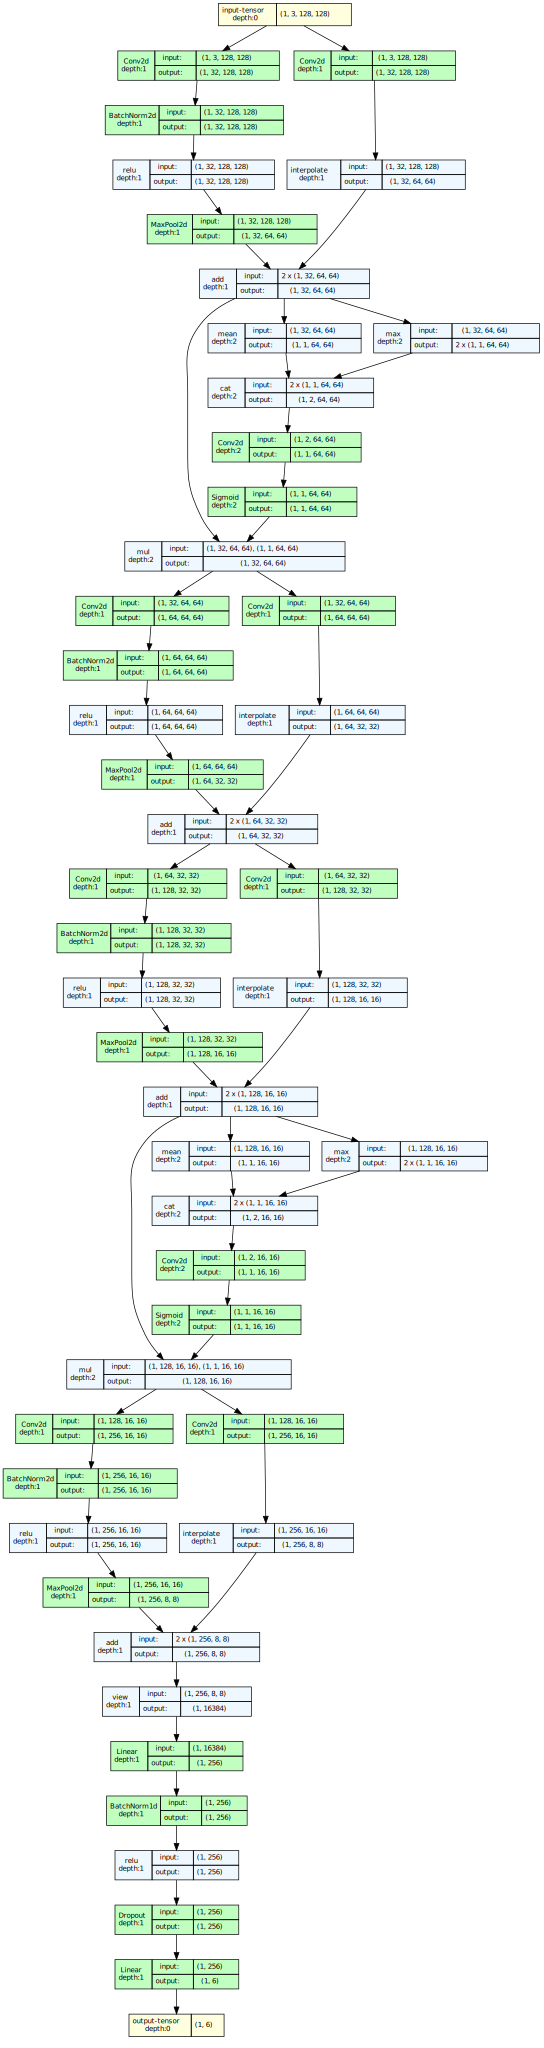


=== EFFICIENTNET-B0 ARCHITECTURE ===


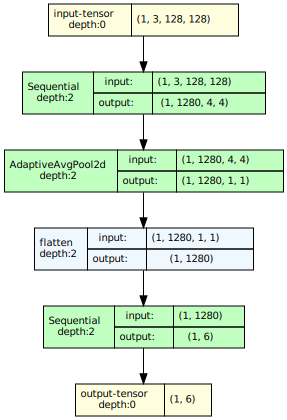

In [27]:
# 1. Install graphviz dependencies directly into the runtime environment
!apt-get install -y graphviz libgraphviz-dev > /dev/null
!pip install torchview graphviz > /dev/null

from torchview import draw_graph
import matplotlib.pyplot as plt

# 2. Build dummy inputs mimicking your dataloader tensor allocations
# Custom CNN and EfficientNet expect (Batch, Channels, Height, Width)
batch_input_cnn_eff = torch.randn(1, 3, 128, 128).to(device)

print("[!] Generating Architectural Graph Diagrams...")

# 3. Generate Graph for Custom CNN (Set depth=3 to cleanly expand custom sub-blocks)
cnn_graph = draw_graph(
    model_cnn,
    input_data=batch_input_cnn_eff,
    device=device,
    depth=3,
    graph_name="Custom_Attention_CNN"
)

# 4. Generate Graph for EfficientNet-B0
eff_graph = draw_graph(
    model_eff,
    input_data=batch_input_cnn_eff,
    device=device,
    depth=2,
    graph_name="EfficientNet_B0"
)

# 5. Display the Visual Architecture Graphs inline
print("\n=== CUSTOM ATTENTION CNN ARCHITECTURE ===")
display(cnn_graph.visual_graph)

print("\n=== EFFICIENTNET-B0 ARCHITECTURE ===")
display(eff_graph.visual_graph)

In [21]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_network_pipeline(model, train_loader, val_loader, criterion, lr=3e-4, epochs=15, name="Model"):
    """
    Standard, non-destructive training engine that keeps solar panel images completely intact.
    """
    # High-regularization weight decay to prevent the model from memorizing the pristine images
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n--- Launching Training Profile for: {name} ---")
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = (correct_train / total_train) * 100
        scheduler.step()

        # Validation Loop
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / total_val) * 100

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% || Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")
    return history


# =====================================================================
#  TRAINING EXECUTION HUB (TUNING AREA)
# =====================================================================

# --- MODEL 1: HAND-BUILT CUSTOM RESID-ATTENTION CNN ---
model_cnn = SolarPanelCNN(num_classes=num_classes).to(device)

# TUNING AREA 1: Adjust Custom Loss Hyperparameters
# Increase gamma to focus on harder anomalies; increase alpha_anomaly to penalize misclassified defects more heavily
criterion_cnn = AsymmetricFocalLoss(
    clean_idx=class_names.index('Clean'),
    gamma=2.5,            # Focuses optimization on hard-to-classify visual inconsistencies
    alpha_anomaly=2.5     # Smooth mathematical penalty multiplier for missing faults
)

# TUNING AREA 2: Play with the Learning Rate
cnn_learning_rate = 1e-4

cnn_history = train_network_pipeline(
    model=model_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_cnn,
    lr=cnn_learning_rate,
    epochs=15,
    name="Custom CNN (Intact Images + Tuned Loss)"
)


# --- MODEL 2: TUNED EFFICIENTNET-B0 ---
model_eff = SolarPanelEfficientNet(num_classes=num_classes).to(device)
eff_history = train_network_pipeline(
    model=model_eff,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(), # Standard baseline target
    lr=2e-4,
    epochs=15,
    name="EfficientNet-B0"
)


# --- MODEL 3: VISION TRANSFORMER (ViT) ---
model_vit = SolarPanelViT(num_classes=num_classes).to(device)
vit_history = train_network_pipeline(
    model=model_vit,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(), # Standard baseline target
    lr=1e-4,
    epochs=15,
    name="Vision Transformer (ViT)"
)


--- Launching Training Profile for: Custom CNN (Intact Images + Tuned Loss) ---
Epoch [01/15] -> Loss: 1.1345 | Acc: 43.50% || Val Loss: 0.8758 | Val Acc: 57.06%
Epoch [02/15] -> Loss: 0.9391 | Acc: 52.26% || Val Loss: 0.8605 | Val Acc: 58.19%
Epoch [03/15] -> Loss: 0.8331 | Acc: 58.76% || Val Loss: 0.7600 | Val Acc: 58.19%
Epoch [04/15] -> Loss: 0.7251 | Acc: 59.32% || Val Loss: 0.8008 | Val Acc: 57.63%
Epoch [05/15] -> Loss: 0.7425 | Acc: 59.32% || Val Loss: 0.7375 | Val Acc: 65.54%
Epoch [06/15] -> Loss: 0.6666 | Acc: 63.42% || Val Loss: 0.7534 | Val Acc: 58.76%
Epoch [07/15] -> Loss: 0.6377 | Acc: 64.97% || Val Loss: 0.7366 | Val Acc: 61.02%
Epoch [08/15] -> Loss: 0.5735 | Acc: 68.64% || Val Loss: 0.7090 | Val Acc: 64.41%
Epoch [09/15] -> Loss: 0.5391 | Acc: 69.21% || Val Loss: 0.7289 | Val Acc: 63.84%
Epoch [10/15] -> Loss: 0.5087 | Acc: 72.32% || Val Loss: 0.6977 | Val Acc: 64.97%
Epoch [11/15] -> Loss: 0.5242 | Acc: 71.47% || Val Loss: 0.6932 | Val Acc: 64.97%
Epoch [12/15] -> 

100%|██████████| 330M/330M [00:01<00:00, 186MB/s]



--- Launching Training Profile for: Vision Transformer (ViT) ---
Epoch [01/15] -> Loss: 1.2859 | Acc: 49.86% || Val Loss: 0.6795 | Val Acc: 72.88%
Epoch [02/15] -> Loss: 0.5708 | Acc: 79.38% || Val Loss: 0.6383 | Val Acc: 77.40%
Epoch [03/15] -> Loss: 0.4263 | Acc: 85.31% || Val Loss: 0.4319 | Val Acc: 86.44%
Epoch [04/15] -> Loss: 0.2526 | Acc: 90.68% || Val Loss: 0.4934 | Val Acc: 81.36%
Epoch [05/15] -> Loss: 0.2488 | Acc: 90.40% || Val Loss: 0.4675 | Val Acc: 85.88%
Epoch [06/15] -> Loss: 0.1807 | Acc: 93.79% || Val Loss: 0.3699 | Val Acc: 88.14%
Epoch [07/15] -> Loss: 0.1182 | Acc: 95.34% || Val Loss: 0.3416 | Val Acc: 88.70%
Epoch [08/15] -> Loss: 0.1190 | Acc: 95.76% || Val Loss: 0.3737 | Val Acc: 88.14%
Epoch [09/15] -> Loss: 0.0661 | Acc: 98.31% || Val Loss: 0.3725 | Val Acc: 89.83%
Epoch [10/15] -> Loss: 0.0388 | Acc: 99.15% || Val Loss: 0.3673 | Val Acc: 89.83%
Epoch [11/15] -> Loss: 0.0417 | Acc: 99.01% || Val Loss: 0.3920 | Val Acc: 89.83%
Epoch [12/15] -> Loss: 0.0265 | 


 METRIC CLASSIFICATION REPORT FOR SUB-MODEL: CUSTOM CNN
                   precision    recall  f1-score   support

        Bird-drop       0.65      0.82      0.73        45
            Clean       0.60      0.44      0.51        34
            Dusty       0.90      0.65      0.76        43
Electrical-damage       0.62      0.81      0.70        16
  Physical-Damage       0.57      0.42      0.48        19
     Snow-Covered       0.66      0.95      0.78        20

         accuracy                           0.68       177
        macro avg       0.67      0.68      0.66       177
     weighted avg       0.69      0.68      0.67       177


 METRIC CLASSIFICATION REPORT FOR SUB-MODEL: TUNED EFFICIENTNET
                   precision    recall  f1-score   support

        Bird-drop       0.84      0.93      0.88        45
            Clean       0.78      0.85      0.82        34
            Dusty       0.94      0.67      0.78        43
Electrical-damage       0.87      0.81      0.84

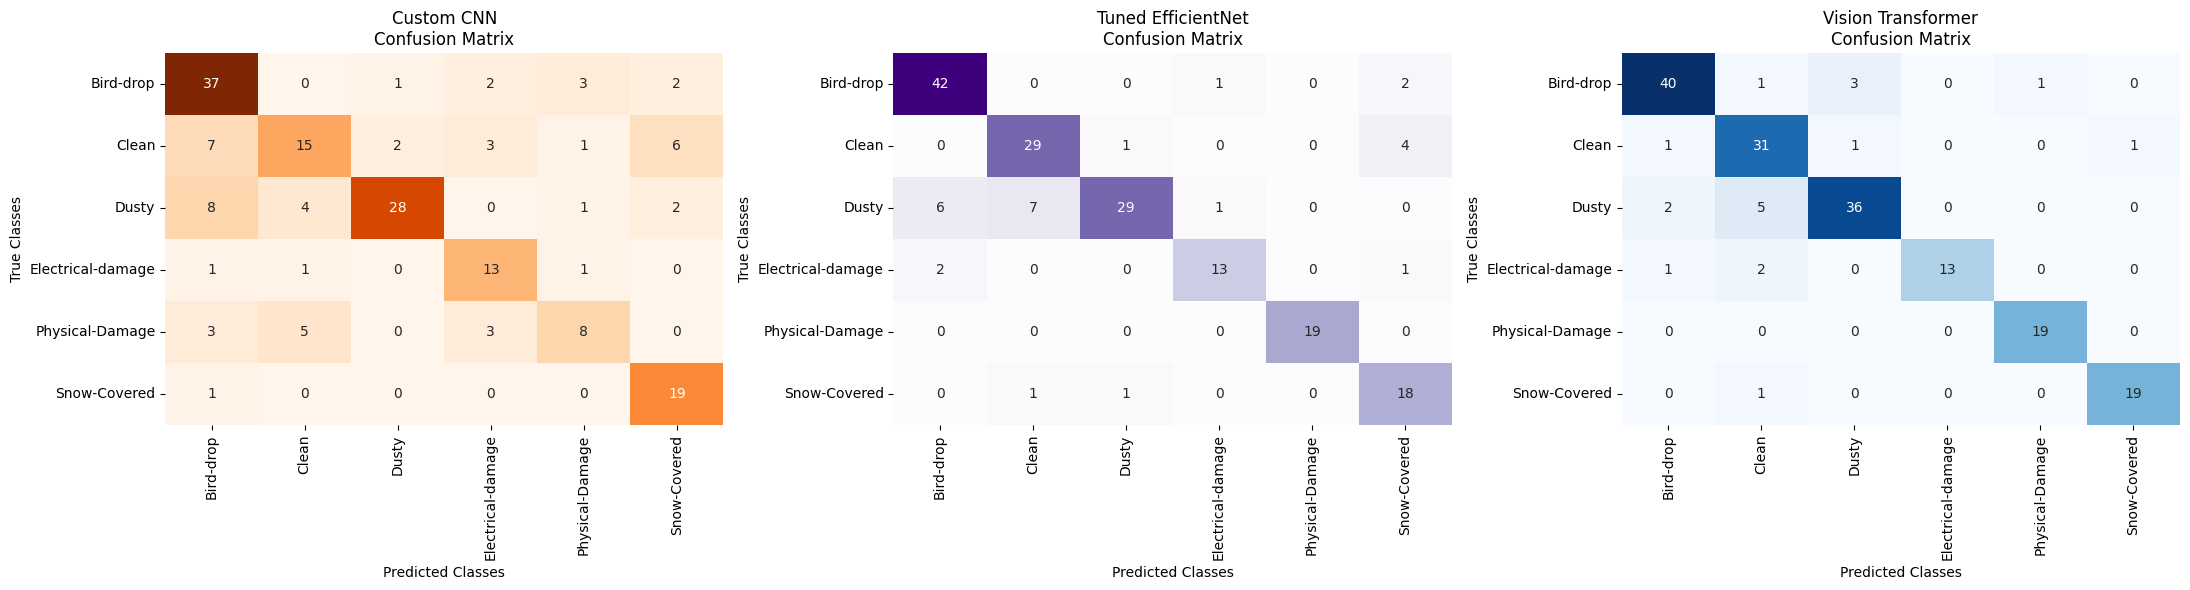

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def generate_academic_plots(models_dict, data_loader, classes, target_device):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    for idx, (name, target_model) in enumerate(models_dict.items()):
        target_model.eval()
        preds, truths = [], []

        with torch.no_grad():
            for images, labels in data_loader:
                images = images.to(target_device)
                outputs = target_model(images)
                _, predicted = torch.max(outputs, 1)
                preds.extend(predicted.cpu().numpy())
                truths.extend(labels.numpy())

        print("\n" + "="*70)
        print(f" METRIC CLASSIFICATION REPORT FOR SUB-MODEL: {name.upper()}")
        print("="*70)
        print(classification_report(truths, preds, target_names=classes, zero_division=0))

        cm = confusion_matrix(truths, preds)
        current_cmap = 'Oranges' if idx == 0 else 'Purples' if idx == 1 else 'Blues'

        sns.heatmap(cm, annot=True, fmt='d', cmap=current_cmap,
                    xticklabels=classes, yticklabels=classes, ax=axes[idx], cbar=False)
        axes[idx].set_title(f'{name}\nConfusion Matrix')
        axes[idx].set_xlabel('Predicted Classes')
        axes[idx].set_ylabel('True Classes')

    plt.tight_layout()
    plt.show()

active_eval_hub = {
    "Custom CNN": model_cnn,
    "Tuned EfficientNet": model_eff,
    "Vision Transformer": model_vit
}

generate_academic_plots(active_eval_hub, val_loader, class_names, device)

Click below to upload a test image for cross-architecture explainability analysis:


Saving dusty.jpg to dusty (1).jpg

[!] Generating Cross-Architecture Heatmaps for: dusty (1).jpg


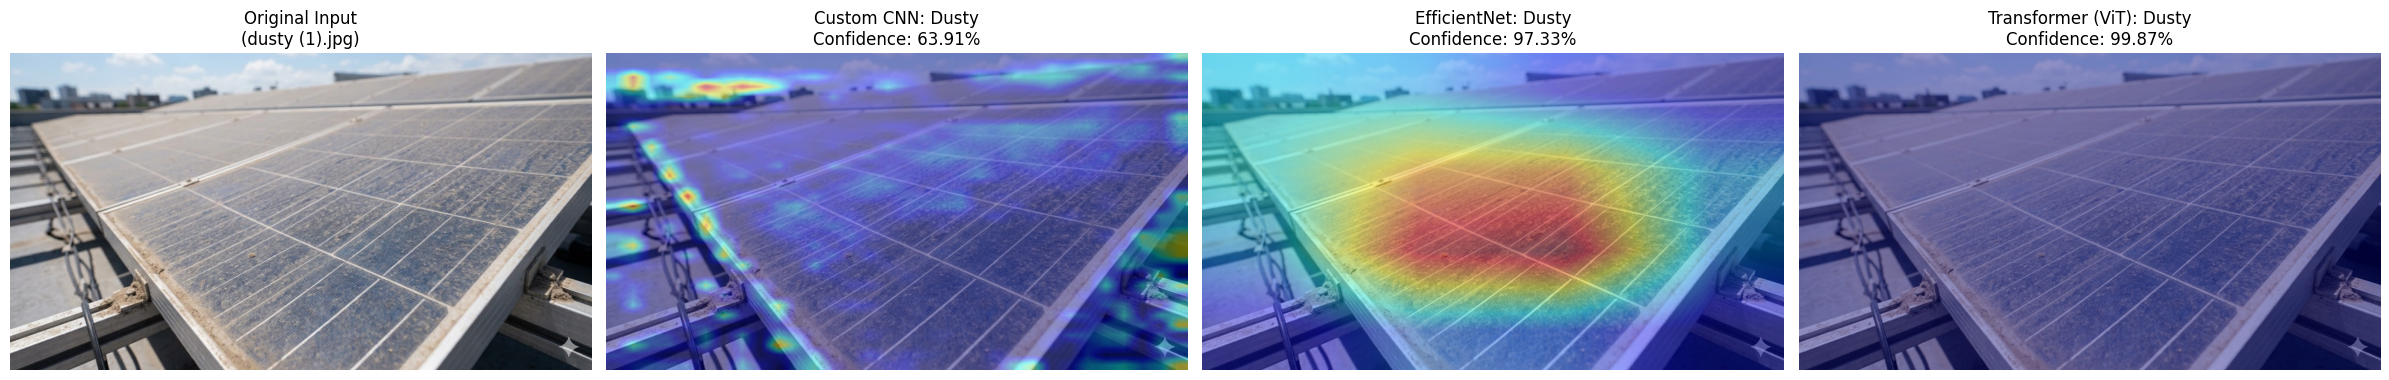

In [31]:
import os
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

def generate_cnn_gradcam(model, img_tensor, target_layer):
    """Generates standard 2D convolutional Grad-CAM heatmaps cleanly handling 3D tensors."""
    model.eval()
    gradients_container = []
    activations_container = []

    def hook_backward(module, grad_in, grad_out):
        gradients_container.append(grad_out[0])
    def hook_forward(module, input, output):
        activations_container.append(output)

    h1 = target_layer.register_forward_hook(hook_forward)
    h2 = target_layer.register_full_backward_hook(hook_backward)

    logits = model(img_tensor)
    probs = torch.softmax(logits, dim=1)[0]
    confidence, class_idx = torch.max(probs, dim=0)

    model.zero_grad()
    logits[0, class_idx].backward()

    h1.remove()
    h2.remove()

    # Calculate channel weights via global average pooling of gradients
    pooled_gradients = torch.mean(gradients_container[0], dim=[0, 2, 3])

    # Strip the batch dimension [Batch, Channels, Height, Width] -> [Channels, Height, Width]
    activations = activations_container[0][0]

    # Differentiable Element-wise channel multiplication
    for i in range(activations.shape[0]):
        activations[i] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=0).detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap, class_idx.item(), confidence.item()

def generate_vit_gradcam(model, img_tensor, target_layer):
    """Generates Token Activation Maps by reshaping Transformer Sequence Blocks."""
    model.eval()
    gradients_container = []
    activations_container = []

    def hook_backward(module, grad_in, grad_out):
        gradients_container.append(grad_out[0])
    def hook_forward(module, input, output):
        activations_container.append(output)

    h1 = target_layer.register_forward_hook(hook_forward)
    h2 = target_layer.register_full_backward_hook(hook_backward)

    logits = model(img_tensor)
    probs = torch.softmax(logits, dim=1)[0]
    confidence, class_idx = torch.max(probs, dim=0)

    model.zero_grad()
    logits[0, class_idx].backward()

    h1.remove()
    h2.remove()

    # ViT Encoder Layer output is [Batch, Tokens (197), Channels (768)]
    grads = gradients_container[0][0][1:, :]
    acts = activations_container[0][0][1:, :]

    weights = torch.mean(grads, dim=0)
    heatmap = torch.sum(acts * weights, dim=1)
    heatmap = heatmap.reshape(14, 14).detach().cpu().numpy()

    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap, class_idx.item(), confidence.item()

def overlay_heatmap_on_image(image_path, heatmap):
    orig_img = cv2.imread(image_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    height, width, _ = orig_img.shape

    resized_heatmap = cv2.resize(heatmap, (width, height))
    resized_heatmap = np.uint8(255 * resized_heatmap)
    color_heatmap = cv2.applyColorMap(resized_heatmap, cv2.COLORMAP_JET)
    color_heatmap = cv2.cvtColor(color_heatmap, cv2.COLOR_BGR2RGB)

    return cv2.addWeighted(orig_img, 0.6, color_heatmap, 0.4, 0)

def run_triple_gradcam_comparison(image_path, cnn_model, eff_model, vit_model, classes, transform_pipeline, target_device):
    orig_img = Image.open(image_path).convert('RGB')
    img_tensor = transform_pipeline(orig_img).unsqueeze(0).to(target_device)

    # Automated hook target configurations
    cnn_layer = cnn_model.conv3
    eff_layer = eff_model.base_model.features[-1]
    vit_layer = vit_model.base_vit.encoder.layers[-1]

    # Extract maps safely
    cnn_map, cnn_idx, cnn_conf = generate_cnn_gradcam(cnn_model, img_tensor, cnn_layer)
    eff_map, eff_idx, eff_conf = generate_cnn_gradcam(eff_model, img_tensor, eff_layer)
    vit_map, vit_idx, vit_conf = generate_vit_gradcam(vit_model, img_tensor, vit_layer)

    # Process overlays
    cnn_overlay = overlay_heatmap_on_image(image_path, cnn_map)
    eff_overlay = overlay_heatmap_on_image(image_path, eff_map)
    vit_overlay = overlay_heatmap_on_image(image_path, vit_map)

    # Render final 4-Panel Figure Comparison via matplotlib
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    axes[0].imshow(np.array(orig_img))
    axes[0].set_title(f"Original Input\n({os.path.basename(image_path)})")
    axes[0].axis('off')

    axes[1].imshow(cnn_overlay)
    axes[1].set_title(f"Custom CNN: {classes[cnn_idx]}\nConfidence: {cnn_conf*100:.2f}%")
    axes[1].axis('off')

    axes[2].imshow(eff_overlay)
    axes[2].set_title(f"EfficientNet: {classes[eff_idx]}\nConfidence: {eff_conf*100:.2f}%")
    axes[2].axis('off')

    axes[3].imshow(vit_overlay)
    axes[3].set_title(f"Transformer (ViT): {classes[vit_idx]}\nConfidence: {vit_conf*100:.2f}%")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN EXECUTION ---
print("Click below to upload a test image for cross-architecture explainability analysis:")
uploaded = files.upload()

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"\n[!] Generating Cross-Architecture Heatmaps for: {uploaded_filename}")

    try:
        run_triple_gradcam_comparison(
            image_path=uploaded_filename,
            cnn_model=model_cnn,
            eff_model=model_eff,
            vit_model=model_vit,
            classes=class_names,
            transform_pipeline=val_transforms,
            target_device=device
        )
    except Exception as e:
        print(f"\n[!] Execution Pass Error: {e}")
        print("Please verify that all model blocks from earlier cells have been completely executed.")
else:
    print("No image file was uploaded.")

Click below to upload a test image for cross-architecture explainability analysis:


Saving bird shit.jpg to bird shit (1).jpg

[!] Generating Cross-Architecture Heatmaps for: bird shit (1).jpg


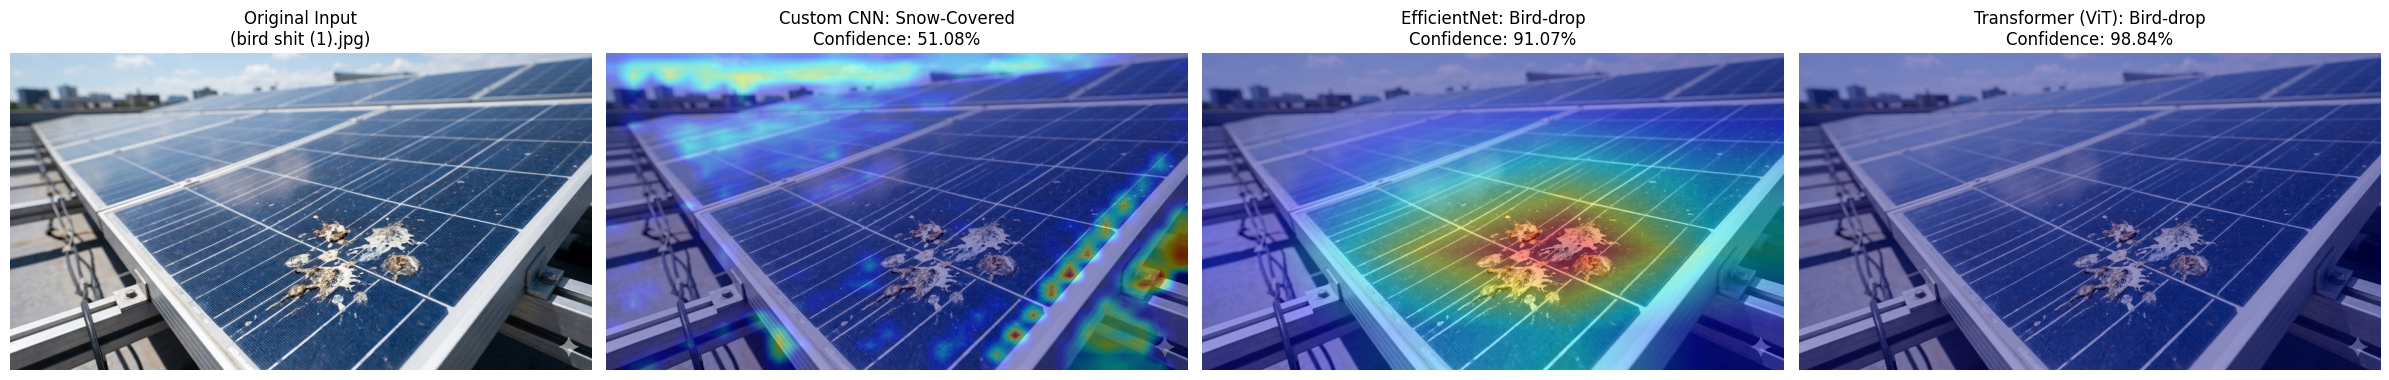

In [32]:
import os
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

def generate_cnn_gradcam(model, img_tensor, target_layer):
    """Generates standard 2D convolutional Grad-CAM heatmaps cleanly handling 3D tensors."""
    model.eval()
    gradients_container = []
    activations_container = []

    def hook_backward(module, grad_in, grad_out):
        gradients_container.append(grad_out[0])
    def hook_forward(module, input, output):
        activations_container.append(output)

    h1 = target_layer.register_forward_hook(hook_forward)
    h2 = target_layer.register_full_backward_hook(hook_backward)

    logits = model(img_tensor)
    probs = torch.softmax(logits, dim=1)[0]
    confidence, class_idx = torch.max(probs, dim=0)

    model.zero_grad()
    logits[0, class_idx].backward()

    h1.remove()
    h2.remove()

    # Calculate channel weights via global average pooling of gradients
    pooled_gradients = torch.mean(gradients_container[0], dim=[0, 2, 3])

    # Strip the batch dimension [Batch, Channels, Height, Width] -> [Channels, Height, Width]
    activations = activations_container[0][0]

    # Differentiable Element-wise channel multiplication
    for i in range(activations.shape[0]):
        activations[i] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=0).detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap, class_idx.item(), confidence.item()

def generate_vit_gradcam(model, img_tensor, target_layer):
    """Generates Token Activation Maps by reshaping Transformer Sequence Blocks."""
    model.eval()
    gradients_container = []
    activations_container = []

    def hook_backward(module, grad_in, grad_out):
        gradients_container.append(grad_out[0])
    def hook_forward(module, input, output):
        activations_container.append(output)

    h1 = target_layer.register_forward_hook(hook_forward)
    h2 = target_layer.register_full_backward_hook(hook_backward)

    logits = model(img_tensor)
    probs = torch.softmax(logits, dim=1)[0]
    confidence, class_idx = torch.max(probs, dim=0)

    model.zero_grad()
    logits[0, class_idx].backward()

    h1.remove()
    h2.remove()

    # ViT Encoder Layer output is [Batch, Tokens (197), Channels (768)]
    grads = gradients_container[0][0][1:, :]
    acts = activations_container[0][0][1:, :]

    weights = torch.mean(grads, dim=0)
    heatmap = torch.sum(acts * weights, dim=1)
    heatmap = heatmap.reshape(14, 14).detach().cpu().numpy()

    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap, class_idx.item(), confidence.item()

def overlay_heatmap_on_image(image_path, heatmap):
    orig_img = cv2.imread(image_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    height, width, _ = orig_img.shape

    resized_heatmap = cv2.resize(heatmap, (width, height))
    resized_heatmap = np.uint8(255 * resized_heatmap)
    color_heatmap = cv2.applyColorMap(resized_heatmap, cv2.COLORMAP_JET)
    color_heatmap = cv2.cvtColor(color_heatmap, cv2.COLOR_BGR2RGB)

    return cv2.addWeighted(orig_img, 0.6, color_heatmap, 0.4, 0)

def run_triple_gradcam_comparison(image_path, cnn_model, eff_model, vit_model, classes, transform_pipeline, target_device):
    orig_img = Image.open(image_path).convert('RGB')
    img_tensor = transform_pipeline(orig_img).unsqueeze(0).to(target_device)

    # Automated hook target configurations
    cnn_layer = cnn_model.conv3
    eff_layer = eff_model.base_model.features[-1]
    vit_layer = vit_model.base_vit.encoder.layers[-1]

    # Extract maps safely
    cnn_map, cnn_idx, cnn_conf = generate_cnn_gradcam(cnn_model, img_tensor, cnn_layer)
    eff_map, eff_idx, eff_conf = generate_cnn_gradcam(eff_model, img_tensor, eff_layer)
    vit_map, vit_idx, vit_conf = generate_vit_gradcam(vit_model, img_tensor, vit_layer)

    # Process overlays
    cnn_overlay = overlay_heatmap_on_image(image_path, cnn_map)
    eff_overlay = overlay_heatmap_on_image(image_path, eff_map)
    vit_overlay = overlay_heatmap_on_image(image_path, vit_map)

    # Render final 4-Panel Figure Comparison via matplotlib
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    axes[0].imshow(np.array(orig_img))
    axes[0].set_title(f"Original Input\n({os.path.basename(image_path)})")
    axes[0].axis('off')

    axes[1].imshow(cnn_overlay)
    axes[1].set_title(f"Custom CNN: {classes[cnn_idx]}\nConfidence: {cnn_conf*100:.2f}%")
    axes[1].axis('off')

    axes[2].imshow(eff_overlay)
    axes[2].set_title(f"EfficientNet: {classes[eff_idx]}\nConfidence: {eff_conf*100:.2f}%")
    axes[2].axis('off')

    axes[3].imshow(vit_overlay)
    axes[3].set_title(f"Transformer (ViT): {classes[vit_idx]}\nConfidence: {vit_conf*100:.2f}%")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN EXECUTION ---
print("Click below to upload a test image for cross-architecture explainability analysis:")
uploaded = files.upload()

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"\n[!] Generating Cross-Architecture Heatmaps for: {uploaded_filename}")

    try:
        run_triple_gradcam_comparison(
            image_path=uploaded_filename,
            cnn_model=model_cnn,
            eff_model=model_eff,
            vit_model=model_vit,
            classes=class_names,
            transform_pipeline=val_transforms,
            target_device=device
        )
    except Exception as e:
        print(f"\n[!] Execution Pass Error: {e}")
        print("Please verify that all model blocks from earlier cells have been completely executed.")
else:
    print("No image file was uploaded.")